In [1]:
import numpy as np

import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import struct
import jax.numpy as jnp
import jax
import seaborn
import scienceplots

from matplotlib.ticker import LogLocator, NullFormatter
import struct

import scienceplots
from tqdm import tqdm

plt.style.use(['science','notebook'])

jax.config.update("jax_enable_x64", True)

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
pi = jnp.pi
N = 2**9

L = 2*pi
dx = L/N

nu = 1e-3
kvals = np.arange(0,N//2)

# ----------------------------------------
# Spectral Grid Setup (Memory-Efficient)
# ----------------------------------------

kx , ky , kz  = np.meshgrid(jnp.fft.fftfreq(N, dx)*(2*pi),jnp.fft.fftfreq(N, dx)*(2*pi), jnp.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = np.stack([kx,ky,kz])

k_sq = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

k = np.sqrt(k_sq)

derivative_operator = 1j*k_vec

shells = np.arange(-0.5, N//2 + 1 , 1.)
shells[0] = 0.
# ----------------------------------------
# Dealiasing and Projection Utilities
# ----------------------------------------

alias_mask = (abs(k_vec[0])<=N//3)*(abs(k_vec[1])<=N//3)*(abs(k_vec[2])<=N//3)

k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask

kint = np.clip(np.round(k,0).astype(int),None,N//2)

/var/folders/br/q1r8zd1d6z50qx6y9z0kdpk00000gn/T/ipykernel_2056/3393664484.py:32: RuntimeWarning: invalid value encountered in divide
  k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask


<Figure size 1100x500 with 0 Axes>

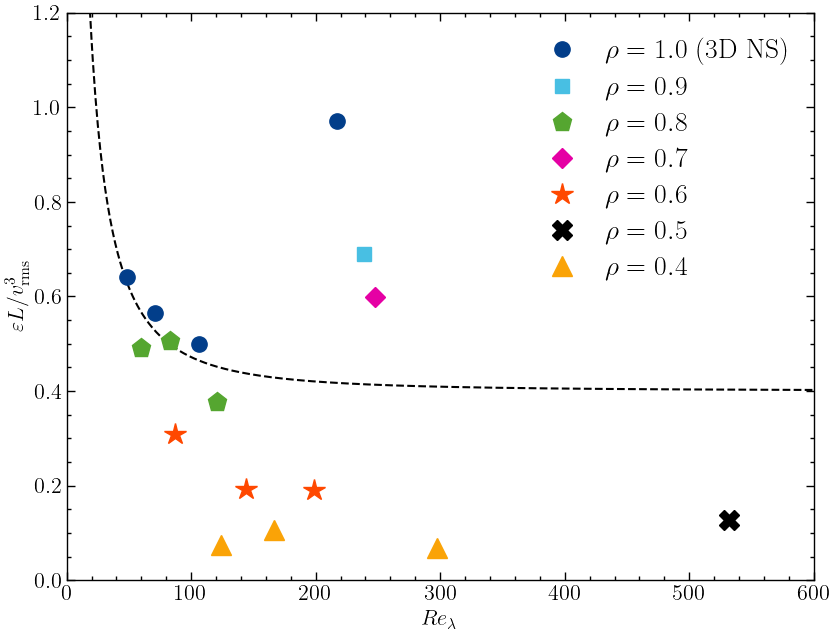

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    'font.family': 'serif',
    'font.size': 25
})

plt.figure(figsize=(11, 5), constrained_layout=True)


# -------------------------
# Load Marco data
# -------------------------
alpha1p0 = np.loadtxt("MarcoData/alpha1p0_Re_epsilon_E_L.out")
alpha0p8 = np.loadtxt("MarcoData/alpha0p8_Re_epsilon_E_L.out")
alpha0p6 = np.loadtxt("MarcoData/alpha0p6_Re_epsilon_E_L.out")
alpha0p4 = np.loadtxt("MarcoData/alpha0p4_Re_epsilon_E_L.out")

def extract_fields(data):
    Re  = data[:, 0]
    eps = data[:, 1]
    E   = data[:, 2]
    L   = data[:, 3]
    urms = np.sqrt(2.0 * E / 3.0)
    return Re, eps, E, urms, L

Re_a1, eps_a1, E_a1, urms_a1, L_a1 = extract_fields(alpha1p0)
Re_a08, eps_a08, E_a08, urms_a08, L_a08 = extract_fields(alpha0p8)
Re_a06, eps_a06, E_a06, urms_a06, L_a06 = extract_fields(alpha0p6)
Re_a04, eps_a04, E_a04, urms_a04, L_a04 = extract_fields(alpha0p4)

# -------------------------
# Load Our data (single-point files)
# -------------------------
def load_single(fname):
    data = np.loadtxt(fname)
    Re  = data[0]
    eps = data[1]
    E   = data[2]
    L   = 2.0 * data[3]   # factor of 2 as in MATLAB
    urms = np.sqrt(2.0 * E / 3.0)
    return Re, eps, E, urms, L

Re_P0p0, eps_P0p0, E_P0p0, urms_P0p0, L_P0p0 = load_single("OurData/Decimation_P0p0_Re_epsilon_E_L.out")
Re_P0p03, eps_P0p03, E_P0p03, urms_P0p03, L_P0p03 = load_single("OurData/Decimation_P0p03_Re_epsilon_E_L.out")
Re_P0p05, eps_P0p05, E_P0p05, urms_P0p05, L_P0p05 = load_single("OurData/Decimation_P0p05_Re_epsilon_E_L.out")
Re_P0p07, eps_P0p07, E_P0p07, urms_P0p07, L_P0p07 = load_single("OurData/Decimation_P0p07_Re_epsilon_E_L.out")
Re_P0p1, eps_P0p1, E_P0p1, urms_P0p1, L_P0p1 = load_single("OurData/Decimation_P0p1_Re_epsilon_E_L.out")
Re_P0p3, eps_P0p3, E_P0p3, urms_P0p3, L_P0p3 = load_single("OurData/Decimation_P0p3_Re_epsilon_E_L.out")
Re_P0p5, eps_P0p5, E_P0p5, urms_P0p5, L_P0p5 = load_single("OurData/Decimation_P0p5_Re_epsilon_E_L.out")


Re_fit = np.arange(1, 601)
fit_curve = 0.2 * (1.0 + np.sqrt(1.0 + (92.0 / Re_fit) ** 2))


def y_expr(eps, L, urms):
    return eps * (L * np.pi / 2.0 / urms**2) / urms**3


plt.figure(figsize=(9, 7))

plt.plot(
    Re_fit, fit_curve,
    'k--', linewidth=1.5)

colors = [
    "#03045e",  
    "#1f6fb2",  
    "#2d6a4f", 
    "#f9c74f",  
    "#f3722c",  
    "#9e2a2b", 
]
markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']



plt.plot(Re_a1,  y_expr(eps_a1,  L_a1,  urms_a1),  'o', ms=11, c='#023e8a',label=r"$\rho = 1.0$ (3D NS)")
plt.plot(Re_P0p0, y_expr(eps_P0p0, L_P0p0, urms_P0p0), 'o', ms=11, c='#023e8a')

plt.plot(Re_P0p1, y_expr(eps_P0p1, L_P0p1, urms_P0p1), 's', ms=10,  c= '#48bfe3',label=r"$\rho = 0.9$")

plt.plot(Re_a08, y_expr(eps_a08, L_a08, urms_a08), 'p', ms=14, c='#55a630', label=r"$\rho = 0.8$")

plt.plot(Re_P0p3, y_expr(eps_P0p3, L_P0p3, urms_P0p3), 'D', ms=10, c='#e500a4',label= r"$\rho = 0.7$")

plt.plot(Re_a06, y_expr(eps_a06, L_a06, urms_a06), '*', ms=16, c='#ff4800', label=r"$\rho = 0.6$")

plt.plot(Re_P0p5, y_expr(eps_P0p5, L_P0p5, urms_P0p5), 'X', ms=14, c='k', label=r"$\rho = 0.5$")

plt.plot(Re_a04, y_expr(eps_a04, L_a04, urms_a04), '^', ms=14, c ='#faa307',label=r"$\rho = 0.4$")

plt.ylim(0, 1.2)
plt.xlim(0, 600)

plt.xlabel(r"$Re_\lambda$")
plt.ylabel(r"$\varepsilon L / v_{\mathrm{rms}}^3$")

plt.legend(
    frameon=False,
    fontsize=20,
    loc="upper right",
    handlelength=1.5,
    labelspacing=0.4
)

plt.grid(False)
plt.tight_layout()

plt.savefig('dissipativeanomaly', dpi = 300)
plt.show()


In [5]:
wswedges_0p0 = np.load('QR_Data/wsw_sss_PDF_0p0.npz')['bins_wsw']
sssedges_0p0= np.load('QR_Data/wsw_sss_PDF_0p0.npz')['bins_sss']
wsw_0p0 =  np.load('QR_Data/wsw_sss_PDF_0p0.npz')['PDF_wsw']
sss_0p0 =  np.load('QR_Data/wsw_sss_PDF_0p0.npz')['PDF_sss']


wswedges_0p1 = np.load('QR_Data/wsw_sss_PDF_0p1.npz')['bins_wsw']
sssedges_0p1= np.load('QR_Data/wsw_sss_PDF_0p1.npz')['bins_sss']
wsw_0p1 =  np.load('QR_Data/wsw_sss_PDF_0p1.npz')['PDF_wsw']
sss_0p1 =  np.load('QR_Data/wsw_sss_PDF_0p1.npz')['PDF_sss']




wswedges_0p3 = np.load('QR_Data/wsw_sss_PDF_0p3.npz')['bins_wsw']
sssedges_0p3= np.load('QR_Data/wsw_sss_PDF_0p3.npz')['bins_sss']
wsw_0p3 =  np.load('QR_Data/wsw_sss_PDF_0p3.npz')['PDF_wsw']
sss_0p3 =  np.load('QR_Data/wsw_sss_PDF_0p3.npz')['PDF_sss']





wswedges_0p5 = np.load('QR_Data/wsw_sss_PDF_0p5.npz')['bins_wsw']
sssedges_0p5= np.load('QR_Data/wsw_sss_PDF_0p5.npz')['bins_sss']
wsw_0p5 =  np.load('QR_Data/wsw_sss_PDF_0p5.npz')['PDF_wsw']
sss_0p5 =  np.load('QR_Data/wsw_sss_PDF_0p5.npz')['PDF_sss']





wswedges_D2p95 = np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['bins_wsw']
sssedges_D2p95= np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['bins_sss']
wsw_D2p95 =  np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['PDF_wsw']
sss_D2p95 =  np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['PDF_sss']


wswedges_D2p80 = np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['bins_wsw']
sssedges_D2p80= np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['bins_sss']
wsw_D2p80 =  np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['PDF_wsw']
sss_D2p80 =  np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['PDF_sss']


In [6]:
rho = np.array([0.97,0.95,0.93,0.9,0.7,0.5])

NOT_Normalized_errors = np.array([0.012691143990221788,0.019542753685661756,0.0238908076000608,0.014774218659270874,0.021671289795209006,0.04844376528130186])

In [7]:
Dim = np.array([3.0 , 2.98 , 2.95 , 2.90 , 2.8])

Re_lam_fractal = np.array([216.81787252, 223.29161916, 219.14386875, 256.35782327,258.03139576])

Normalized_fract_eps = np.array([0.47687394, 0.43160262, 0.4452681 , 0.33712886, 0.31287468])

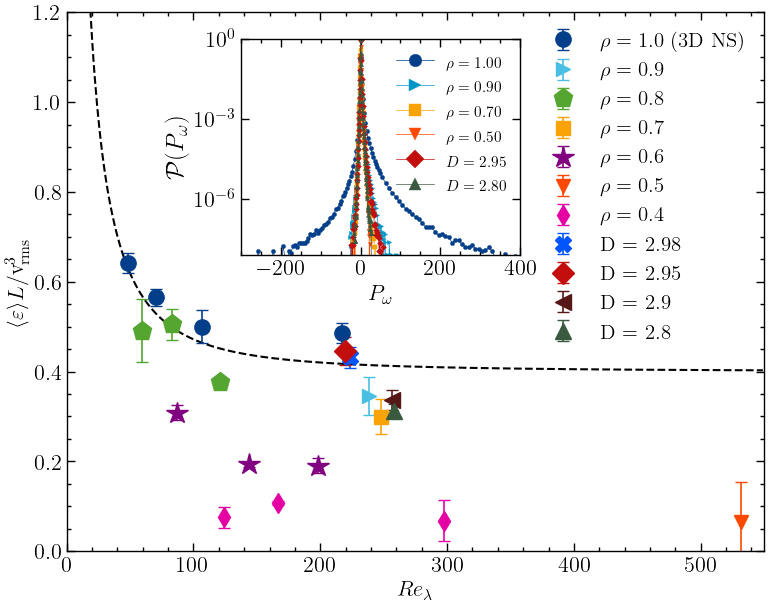

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 25
})

# -------------------------
# Load Marco data
# -------------------------
alpha1p0 = np.loadtxt("MarcoData/alpha1p0_Re_epsilon_E_L.out")
alpha0p8 = np.loadtxt("MarcoData/alpha0p8_Re_epsilon_E_L.out")
alpha0p6 = np.loadtxt("MarcoData/alpha0p6_Re_epsilon_E_L.out")
alpha0p4 = np.loadtxt("MarcoData/alpha0p4_Re_epsilon_E_L.out")

def extract_fields(data):
    Re  = data[:, 0]
    eps = data[:, 1]
    E   = data[:, 2]
    L   = data[:, 3]
    urms = np.sqrt(2.0 * E / 3.0)
    return Re, eps, E, urms, L

Re_a1, eps_a1, E_a1, urms_a1, L_a1 = extract_fields(alpha1p0)
Re_a08, eps_a08, E_a08, urms_a08, L_a08 = extract_fields(alpha0p8)
Re_a06, eps_a06, E_a06, urms_a06, L_a06 = extract_fields(alpha0p6)
Re_a04, eps_a04, E_a04, urms_a04, L_a04 = extract_fields(alpha0p4)

# -------------------------
# Load Our data
# -------------------------
def load_single(fname):
    data = np.loadtxt(fname)
    Re  = data[0]
    eps = data[1]
    E   = data[2]
    L   = data[3]
    urms = np.sqrt(2.0 * E / 3.0)
    return Re, eps, E, urms, L

Re_P0p0, eps_P0p0, E_P0p0, urms_P0p0, L_P0p0 = load_single("OurData/Decimation_P0p0_Re_epsilon_E_L.out")
Re_P0p1, eps_P0p1, E_P0p1, urms_P0p1, L_P0p1 = load_single("OurData/Decimation_P0p1_Re_epsilon_E_L.out")
Re_P0p3, eps_P0p3, E_P0p3, urms_P0p3, L_P0p3 = load_single("OurData/Decimation_P0p3_Re_epsilon_E_L.out")
Re_P0p5, eps_P0p5, E_P0p5, urms_P0p5, L_P0p5 = load_single("OurData/Decimation_P0p5_Re_epsilon_E_L.out")

# -------------------------
# Theory fit
# -------------------------
Re_fit = np.arange(1, 550)
fit_curve = 0.2 * (1.0 + np.sqrt(1.0 + (92.0 / Re_fit) ** 2))

def y_expr(eps, L, urms):
    return eps * (L * np.pi / 2.0 / urms**2) / urms**3

# -------------------------
# Main figure
# -------------------------
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(Re_fit, fit_curve, 'k--', lw=1.5)
# ax.plot(Re_fit, 5e1*Re_fit**(-1.0), 'k--', lw=1.5)

ax.errorbar(Re_a1,  y_expr(eps_a1,  L_a1,  urms_a1), yerr= np.array([0.0366507577087645,0.0188637363934619,0.0224046702958413]),fmt = 'o', ms=11, c='#023e8a', label=r"$\rho = 1.0$ (3D NS)",capsize=4, elinewidth=1.2)
ax.errorbar(Re_P0p0, y_expr(eps_P0p0, L_P0p0, urms_P0p0),yerr = 0.019379582472887198*L_P0p0 ,fmt = 'o', ms=11, c='#023e8a',capsize=4, elinewidth=1.2)

ax.errorbar(Re_P0p1, y_expr(eps_P0p1, L_P0p1, urms_P0p1),yerr = L_P0p1*0.03839972327113949 ,fmt =  '>', ms=10, c='#48bfe3', label=r"$\rho = 0.9$",capsize=4, elinewidth=1.2)
ax.errorbar(Re_a08, y_expr(eps_a08, L_a08, urms_a08),yerr= np.array([0.00877298465968126,0.0339678286906097,0.0699223818938788   ]), fmt = 'p', ms=14, c='#55a630', label=r"$\rho = 0.8$",capsize=4, elinewidth=1.2)
ax.errorbar(Re_P0p3, y_expr(eps_P0p3, L_P0p3, urms_P0p3),yerr =  L_P0p3*0.037158790414211794 ,fmt = 's', ms=10, c= '#faa307', label=r"$\rho = 0.7$",capsize=4, elinewidth=1.2)
ax.errorbar(Re_a06, y_expr(eps_a06, L_a06, urms_a06),yerr= np.array([0.0171884934558546,0.00632510839437471,0.0171884934558546]), fmt =  '*', ms=16, c= 'purple', label=r"$\rho = 0.6$",capsize=4, elinewidth=1.2)
ax.errorbar(Re_P0p5, y_expr(eps_P0p5, L_P0p5, urms_P0p5),yerr = L_P0p5*0.060444059269410676,fmt = 'v', ms=10, c='#ff4800', label=r"$\rho = 0.5$",capsize=4, elinewidth=1.2)
ax.errorbar(Re_a04, y_expr(eps_a04, L_a04, urms_a04), yerr= np.array([ 0.0454603372320144,0.00447334638513376,0.0229684604634616]) ,fmt = 'd' , ms=10, c='#e500a4', label=r"$\rho = 0.4$",capsize=4, elinewidth=1.2)

ax.errorbar(Re_lam_fractal[1], Normalized_fract_eps[1],yerr = 0.02080705729261429*1.1468718894253656,fmt = 'X', ms=11, c='#0055ff', label=f"D = {Dim[1]}",capsize=4, elinewidth=1.2)
ax.errorbar(Re_lam_fractal[2], Normalized_fract_eps[2],yerr = 0.028413510294337786*1.1180636725550663,fmt = 'D', ms=11, c='#c30e0e', label=f"D = {Dim[2]}",capsize=4, elinewidth=1.2)
ax.errorbar(Re_lam_fractal[3], Normalized_fract_eps[3],yerr = 0.02080705729261429*1.0845851806170805,fmt = '<', ms=11, c='#551817', label=f"D = {Dim[3]}",capsize=4, elinewidth=1.2)
ax.errorbar(Re_lam_fractal[4], Normalized_fract_eps[4],yerr = 0.015211107984678044*0.9830272409386134,fmt = '^', ms=11, c='#3a5a40', label=f"D = {Dim[4]}",capsize=4, elinewidth=1.2)

ax.set_xlim(0, 550)
ax.set_ylim(0, 1.2)

ax.set_xlabel(r"$Re_\lambda$")
ax.set_ylabel(r"$ \langle \varepsilon \rangle L/ \text{v}_{\mathrm{rms}}^3$")


# ax.set_xscale('log')          # Set the x-axis to log scale
# ax.set_yscale('log')          # Set the y-axis to log scale

ax.legend(ncols = 1 , frameon=False, fontsize=15, loc="best")
ax.grid(False)

# -------------------------
# Inset (exact manual placement)
# -------------------------
axins = inset_axes(ax,width="40%",height="40%",bbox_to_anchor=(-0.35, -0.05, 1, 1), bbox_transform=ax.transAxes,borderpad=0)

axins.set_xlim(0, 120)
axins.set_ylim(0, 0.9)



colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.9,0.7,0.5]
Dims = [2.95, 2.80]

axins.semilogy(
    wswedges_0p0, wsw_0p0,
    marker=markers[0],
    linestyle="-",
    markersize=3,
    lw = 0.5,
    alpha=1,
    color=colors[0],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[0]:.2f}$",
)

axins.semilogy(
    wswedges_0p1[::2], wsw_0p1[::2],
    marker=markers[1],
    linestyle="-",
        lw = 0.5,
    markersize=3,
    alpha=1,
    color=colors[1],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[1]:.2f}$",
)

axins.semilogy(
    wswedges_0p3[::2], wsw_0p3[::2],
    marker=markers[2],
    linestyle="-",
        lw = 0.5,
    markersize=3,
    alpha=1,
    color=colors[2],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[2]:.2f}$",
)

axins.semilogy(
    wswedges_0p5[::2], wsw_0p5[::2],
    marker=markers[3],
    linestyle="-",
        lw = 0.5,
    markersize=3,
    alpha=1,
    color=colors[3],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[3]:.2f}$",
)



axins.semilogy(
    wswedges_D2p95[::2], wsw_D2p95[::2],
    marker=markers[4],
    linestyle="-",
    markersize=3,
        lw = 0.5,
    alpha=1,
    color=colors[4],
    markeredgewidth=0.3,
    label=fr"$D = 2.95$",
)



axins.semilogy(
    wswedges_D2p80[::2], wsw_D2p80[::2],
    marker=markers[5],
    linestyle="-",
    markersize=3,
        lw = 0.5,
    alpha=1,
    color=colors[5],
    markeredgewidth=0.3,
    label=fr"$D = 2.80$",
)




axins.set_xlabel(r"$P_{\omega}$",fontsize = 16)
axins.set_ylabel(r"$ \mathcal{P}(P_{\omega})$",fontsize = 18)

axins.set_xlim(-300,400)
axins.set_ylim(8e-9,1)

# # -----------------------------
# # Legend
# # -----------------------------
axins.legend(
    loc="upper right",
    ncol=1,
    handlelength=2.5,     
    handleheight=1.5,   
    markerscale=3.0,      
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.4,
    prop={"size": 11},     
)


axins.grid(False)

plt.savefig('Dissp_anamoly.png', dpi = 300)
plt.show()